In [1]:
from src import *

import numpy as np
import matplotlib.pyplot as plt
import os

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from glob import glob

In [2]:
from myutils import cache

In [3]:
plt.rcdefaults()

from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')
del backend_inline

from matplotlib.font_manager import fontManager
fontManager.addfont('src/lmroman10.otf')
del fontManager

plt.rcParams['font.family'] = 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

In [4]:
@cache
def read_est(A):
    file_tree = [
        f'__estimates__/0noise/spade_{A}px/*',
        f'__estimates__/0noise/di_{A}px/*'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.frequency_estimates.var(ddof=0) * c.photons.mean())
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.frequency_estimates.var(ddof=0) * c.photons.mean())

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file
cache hit: reading result from cache file
cache hit: reading result from cache file


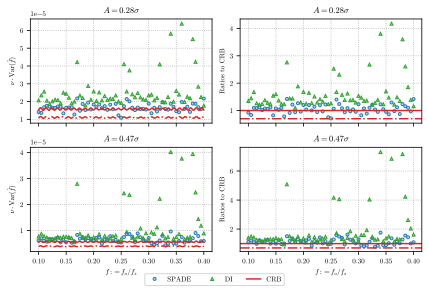

In [62]:
plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ([ax1, ax2],[ax3, ax4]) = plt.subplots(2, 2, figsize=(6, 4), sharex=True)

for ax in (ax1, ax3):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = (1 / FisherInformation([A * DMD.PIXEL_SIZE / 2], x_axis))[0]

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

    line3, = ax.plot(x_axis, crb, 'C3')
    ax.plot(x_axis, 0.7 * crb, 'C3-.')

    ax.grid(True, linestyle=':')

    ax.set_ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')


for ax in (ax2, ax4):
    A = 3 if ax == ax2 else 5

    crb = lambda f: (1 / FisherInformation([A * DMD.PIXEL_SIZE / 2], f))[0]

    di_x, di_y, spade_x, spade_y = read_est(A)

    ax.plot(spade_x, spade_y / crb(spade_x), 
            marker='o', linestyle='', markersize=3,
            markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

    ax.plot(di_x, di_y / crb(di_x),
            marker='^', linestyle='', markersize=3,
            markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

    ax.grid(True, linestyle=':')

    ax.set_ylabel(f'Ratios to CRB')
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.axhline(1, color='C3')
    ax.axhline(0.7, color='C3', linestyle='-.')

ax3.set_xlabel(r'$f := f_o / f_s$')
ax4.set_xlabel(r'$f := f_o / f_s$')


fig.legend([line1, line2, line3], ['SPADE', 'DI', 'CRB'], ncol=3, loc='lower center')
plt.tight_layout()
plt.show()